In [1]:
import pandas as pd
import numpy as np

In [2]:
filename = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv"

In [3]:
!curl -L -o car_price.csv {filename}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1440k  100 1440k    0     0  3693k      0 --:--:-- --:--:-- --:--:-- 3694k


In [4]:
df = pd.read_csv('car_price.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [6]:
df.isna().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [7]:
df.MSRP.describe()

count    1.191400e+04
mean     4.059474e+04
std      6.010910e+04
min      2.000000e+03
25%      2.100000e+04
50%      2.999500e+04
75%      4.223125e+04
max      2.065902e+06
Name: MSRP, dtype: float64

In [8]:
# The column names are not very convenient. Let's make them lowercase and replace spaces with underscores.
df.columns=df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [12]:
# Let's clean also the string columns. We will make them lowercase and replace spaces with underscores.
string_columns = df.select_dtypes('string').columns.to_list()
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')


In [13]:
df.select_dtypes(include='string')

,make,model,engine_fuel_type,transmission_type,driven_wheels,market_category,vehicle_size,vehicle_style
0,bmw,1_series_m,premium_unleaded_(required),manual,rear_wheel_drive,"factory_tuner,luxury,high-performance",compact,coupe
1,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,performance",compact,convertible
2,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,high-performance",compact,coupe
3,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,performance",compact,coupe
4,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,luxury,compact,convertible
...,...,...,...,...,...,...,...,...
11909,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11910,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11911,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11912,acura,zdx,premium_unleaded_(recommended),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback


## Exploratory data analysis

In [26]:
for col in  df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

## Distribution of price

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns   
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

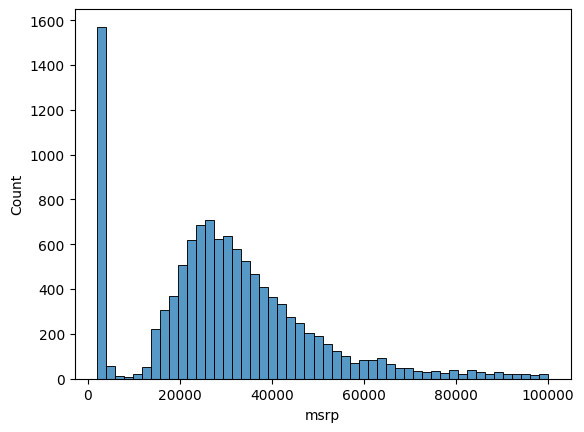

In [37]:
sns.histplot(data=df.query('msrp < 100000'), x='msrp', bins=50)

In [46]:
df[df.msrp < 100000].msrp.describe()

count    11276.000000
mean     30476.444395
std      18633.369504
min       2000.000000
25%      20395.000000
50%      29095.000000
75%      39516.250000
max      99950.000000
Name: msrp, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

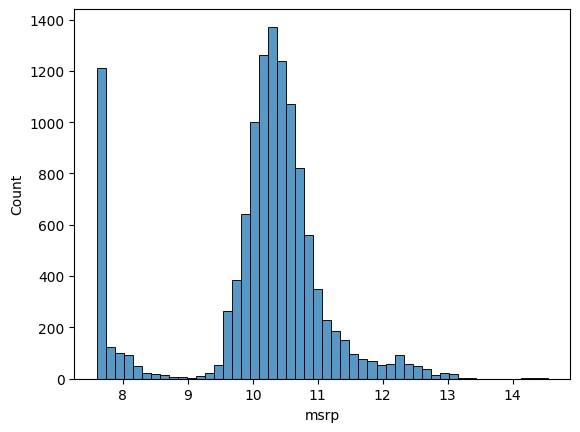

In [50]:
# Get rid of the long tail. Let's apply log transformation to the target variable.
price_logs = np.log1p(df.msrp)
sns.histplot(price_logs, bins=50)

In [51]:
df.isna().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [59]:
df.isna()  # Series — one count per ROW (how many missing fields in each car)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11910,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11911,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11912,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [61]:
df.isna().any()

make                 False
model                False
year                 False
engine_fuel_type      True
engine_hp             True
engine_cylinders      True
transmission_type    False
driven_wheels        False
number_of_doors       True
market_category       True
vehicle_size         False
vehicle_style        False
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [66]:
df[df.isna().any(axis=1)]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
87,nissan,200sx,1996,regular_unleaded,115.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,36,26,2009,2000
88,nissan,200sx,1996,regular_unleaded,115.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,36,26,2009,2000
91,nissan,200sx,1997,regular_unleaded,115.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,35,25,2009,2000
92,nissan,200sx,1997,regular_unleaded,115.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,35,25,2009,2000
93,nissan,200sx,1998,regular_unleaded,115.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,35,25,2009,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11794,subaru,xt,1991,regular_unleaded,145.0,6.0,manual,all_wheel_drive,2.0,NaN,compact,coupe,23,16,640,2000
11809,toyota,yaris_ia,2017,regular_unleaded,106.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,39,30,2031,15950
11810,toyota,yaris_ia,2017,regular_unleaded,106.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,sedan,40,32,2031,17050
11867,gmc,yukon,2015,premium_unleaded_(recommended),420.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,4dr_suv,21,15,549,64520


## Setting up the Validation Framework

In [67]:
# We need to split our data into Trainining Validation and Test sets.
# We will do a 60/20/20 split. We will use Scikit-Learn's train_test_split function to do that.
n = len(df)
n_test = int(n * 0.2)
n_val = int(n * 0.2)
n_train = n - n_test - n_val

In [71]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [78]:
# we need to shuffle the data before splitting it. Otherwise, we will have a problem with the distribution of the target variable in the train, validation and test sets.
# we use arange to create an array of indices, then we shuffle it and then we use it to split the data.
idx = np.arange(n)
np.random
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [79]:
print(df_train.msrp.describe())
print(df_val.msrp.describe())
print(df_test.msrp.describe())

count    7.150000e+03
mean     4.063767e+04
std      6.330440e+04
min      2.000000e+03
25%      2.106500e+04
50%      2.999500e+04
75%      4.228875e+04
max      2.065902e+06
Name: msrp, dtype: float64
count    2.382000e+03
mean     4.193309e+04
std      6.170596e+04
min      2.000000e+03
25%      2.116375e+04
50%      3.036250e+04
75%      4.239375e+04
max      1.382750e+06
Name: msrp, dtype: float64
count      2382.000000
mean      39127.514694
std       47261.446238
min        2000.000000
25%       20871.250000
50%       29710.000000
75%       42070.000000
max      497650.000000
Name: msrp, dtype: float64


In [80]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
1480,chevrolet,astro_cargo,2005,regular_unleaded,190.0,6.0,automatic,rear_wheel_drive,3.0,NaN,large,cargo_minivan,20,15,1385,22930
837,saab,9-3,2010,premium_unleaded_(recommended),207.0,4.0,manual,front_wheel_drive,4.0,luxury,midsize,sedan,31,21,376,28900
11023,toyota,tundra,2017,regular_unleaded,381.0,8.0,automatic,four_wheel_drive,4.0,NaN,large,extended_cab_pickup,17,13,2031,42330
4927,ford,freestar,2007,regular_unleaded,201.0,6.0,automatic,front_wheel_drive,4.0,NaN,midsize,cargo_minivan,21,15,5657,19700
9237,toyota,sienna,2017,regular_unleaded,296.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,27,19,2031,32740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1895,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,31,23,873,28675
7157,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,66770
11623,volvo,xc90,2014,regular_unleaded,240.0,6.0,automatic,front_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,25,16,870,39700
1617,dodge,avenger,2014,regular_unleaded,173.0,4.0,automatic,front_wheel_drive,4.0,flex_fuel,midsize,sedan,29,21,1851,20595


In [85]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


In [86]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [87]:
df_train = df_train.drop(columns=['msrp'])
df_val = df_val.drop(columns=['msrp'])
df_test = df_test.drop(columns=['msrp'])

# Linear Regression

In [88]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [ ]:
# Build a baseline model with the numerical features only
numerical = df_train.select_dtypes(include=['int64', 'float64']).columns.to_list()
df_train[numerical].head()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity
0,2005,190.0,6.0,3.0,20,15,1385
1,2010,207.0,4.0,4.0,31,21,376
2,2017,381.0,8.0,4.0,17,13,2031
3,2007,201.0,6.0,4.0,21,15,5657
4,2017,296.0,6.0,4.0,27,19,2031


In [94]:
# drop the number of doors column because it has only one unique value
numerical.remove('number_of_doors')
numerical   

['year',
 'engine_hp',
 'engine_cylinders',
 'highway_mpg',
 'city_mpg',
 'popularity']

In [ ]:
X_train = df_train[numerical].values